# Consensus and AIC diagnostic

Explores four-model votes, SNR checks, and AIC refinements on selected windows. This diagnostic notebook is outside the dataset-building pipeline.


In [22]:
# ==========================================
# 1. IMPORTS AND PATHS
# ==========================================
import os
import sys

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
for _dll_dir in (os.path.join(sys.prefix, "Library", "bin"),
                 os.path.join(sys.prefix, "Library", "mingw-w64", "bin"),
                 sys.prefix):
    if os.path.isdir(_dll_dir):
        os.environ["PATH"] = _dll_dir + os.pathsep + os.environ.get("PATH", "")

import torch  # noqa: E402  (import before obspy/seisbench on Windows)
import logging
logging.getLogger("seisbench").setLevel(logging.ERROR)

from pathlib import Path
import numpy as np


def _find_repo_root(start):
    for p in (start, *start.parents):
        if (p / "data" / "raw").is_dir() and (p / "src").is_dir():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import importlib
import preprocessing_utils as pp
import consensus_utils as cu
importlib.reload(pp)
importlib.reload(cu)

WAVEFORMS_DIR = REPO_ROOT / "data" / "raw" / "waveforms"
INVENTORY_DIR = REPO_ROOT / "data" / "interim" / "preprocessing"
print("Repo root:", REPO_ROOT)

Repo root: M:\Github\TFM_SeismicPhasePicker_ColombianAndes


In [23]:
# ==========================================
# 2. CONFIGURATION
# ==========================================
# Compare three- and four-architecture diagnostic configurations.
MODEL_WEIGHTS = {"PhaseNet": "instance", "EQTransformer": "instance",
                 "EQCCT_P": "original", "EQCCT_S": "original"}
GPD_WEIGHT = "instance"          # separate GPD weight

THRESHOLDS = {"P": 0.40, "S": 0.10}
TOL_SAMPLES = 20                 # 0.2 s at 100 Hz
MIN_AGREEMENT = 3
NOISE_MAX_PROB = 0.15

# Independent P and S vote settings.
MIN_P, THR_P, TOL_P = 3, 0.30, 20   # P: 3 of 4 models, prob >= 0.30, within 0.2 s
MIN_S, THR_S, TOL_S = 2, 0.15, 30   # S: 2 of 4 models, prob >= 0.15, within 0.3 s

# AIC searches locally around each consensus pick.
AIC_HALF_WIN_S = 0.25             # search +/- this many seconds around the pick (refine, not relocate)
AIC_EDGE = 5                     # ignore this many edge samples (AIC dips there)

STATION = "ZAR"
N_CAT = 30                       # event windows for inspection
N_NOISE = 40                     # synthetic-noise windows for false alarms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [24]:
# ==========================================
# 3. LOAD MODELS FOR THE DIAGNOSTIC
# ==========================================
import seisbench.models as sbm

models = cu.load_models(MODEL_WEIGHTS, device=DEVICE)      # configured architectures
gpd = sbm.GPD.from_pretrained(GPD_WEIGHT)
gpd.to(DEVICE)
gpd.eval()
models["GPD"] = gpd
print(f"\nConsensus models ({len(models)}): {list(models)}")

# Retain a three-architecture subset for exploratory comparisons.
models_3 = {k: v for k, v in models.items() if k != "GPD"}

[ok] PhaseNet <- 'instance' on cuda
[ok] EQTransformer <- 'instance' on cuda


KeyboardInterrupt: 

In [ ]:
# ==========================================
# 4. HELPERS
# ==========================================
NPTS = cu.NPTS
fs = cu.SAMPLING_RATE_HZ
station_dir = WAVEFORMS_DIR / STATION
from obspy.signal.trigger import aic_simple


def label(arr, mdls):
    return cu.label_window(arr, "x", STATION, "t", mdls,
                           thresholds=THRESHOLDS, tol_samples=TOL_SAMPLES,
                           min_agreement=MIN_AGREEMENT, noise_max_prob=NOISE_MAX_PROB)


from types import SimpleNamespace


def label_decoupled(arr, mdls):
    """OBS-style: P and S judged by INDEPENDENT consensus. S is only marked when
    >= MIN_S models agree (never fabricated); a strong P alone -> P-only event."""
    picks = cu.run_models_on_window(arr, mdls, thresholds={"P": THR_P, "S": THR_S},
                                    station=STATION[:4])
    p_picks = [p for p in picks if p.phase == "P"]
    s_picks = [p for p in picks if p.phase == "S"]
    cp = cu.consensus_from_picks(p_picks, tol_samples=TOL_P, min_agreement=MIN_P)
    cs = cu.consensus_from_picks(s_picks, tol_samples=TOL_S, min_agreement=MIN_S)
    P = max(cp, key=lambda c: (c.n_models, c.mean_prob)) if cp else None
    S = max(cs, key=lambda c: (c.n_models, c.mean_prob)) if cs else None
    if P is not None and S is not None and S.sample <= P.sample:
        S = None  # S must follow P
    lab = SimpleNamespace(category="unlabelled", p_sample=None, s_sample=None,
                          p_n_models=0, s_n_models=0, p_prob=0.0, s_prob=0.0,
                          snr_db=float("nan"))
    if P is not None:
        lab.category = "earthquake"
        lab.p_sample, lab.p_n_models, lab.p_prob = P.sample, P.n_models, P.mean_prob
        if S is not None:
            lab.s_sample, lab.s_n_models, lab.s_prob = S.sample, S.n_models, S.mean_prob
        lab.snr_db = cu.snr_db_around(arr, P.sample)
        return lab
    if all(p.prob < NOISE_MAX_PROB for p in picks):
        lab.category = "noise"
    else:
        lab.category = "unlabelled"
    return lab


def per_model_probs(arr, floor=0.05):
    st = cu.array_to_stream(arr, station=STATION[:4])
    sc = {m: {"P": 0.0, "S": 0.0} for m in models}
    for name, model in models.items():
        for pk in model.classify(st, P_threshold=floor, S_threshold=floor).picks:
            ph = str(pk.phase).upper()
            if ph in ("P", "S"):
                sc[name][ph] = max(sc[name][ph], float(pk.peak_value))
    return sc


_rng = np.random.default_rng(0)


def synth_noise(arr):
    # Phase-randomized surrogate from the first 25 s of the window.
    seg = arr[:, :2500]
    res = np.zeros((3, NPTS), dtype=np.float32)
    for i in range(3):
        s = seg[i] - seg[i].mean()
        amp = np.interp(np.linspace(0, 1, NPTS // 2 + 1),
                        np.linspace(0, 1, np.fft.rfft(s).size), np.abs(np.fft.rfft(s)))
        n = np.fft.irfft(amp * np.exp(1j * _rng.uniform(0, 2 * np.pi, amp.size)), n=NPTS)
        res[i] = (n / (n.std() + 1e-9) * (s.std() + 1e-9)).astype(np.float32)
    return np.ascontiguousarray(res)


def aic_refine(comp, rough, half_win_s=AIC_HALF_WIN_S, edge=AIC_EDGE):
    # Locate the AIC minimum near the tentative pick.
    h = int(half_win_s * fs)
    a = max(0, rough - h)
    b = min(len(comp), rough + h)
    seg = np.ascontiguousarray(comp[a:b], dtype=np.float64)
    if len(seg) < 2 * edge + 5:
        return rough
    aic = aic_simple(seg)
    interior = aic[edge:len(aic) - edge]
    if len(interior) == 0:
        return rough
    return a + edge + int(np.argmin(interior))


def refine_ps(arr, p_sample, s_sample):
    # Apply AIC on Z for P and on the stronger horizontal for S.
    p_ref = aic_refine(arr[0], p_sample) if p_sample is not None else None
    s_ref = None
    if s_sample is not None:
        w = slice(max(0, s_sample - 100), min(NPTS, s_sample + 100))
        comp = arr[1] if np.abs(arr[1][w]).max() >= np.abs(arr[2][w]).max() else arr[2]
        s_ref = aic_refine(comp, s_sample)
    return p_ref, s_ref


print("Helpers ready: label, per_model_probs, synth_noise, aic_refine, refine_ps.")

Helpers ready: label, per_model_probs, synth_noise, aic_refine, refine_ps.


In [ ]:
# ==========================================
# 5. VALIDATION: recall (3 vs 4 models) + false alarms + AIC refinement stats
# ==========================================
tss = sorted(pp.group_station_windows(station_dir).keys())
cat, noise = [], []
for t_ in tss:
    if len(cat) >= max(N_CAT, N_NOISE):
        break
    a = pp.load_window_array(station_dir, t_, STATION, preprocess=True)
    if a is None:
        continue
    cat.append((t_, a))
    noise.append(synth_noise(a))
cat, noise = cat[:N_CAT], noise[:N_NOISE]

labs4 = [(t_, a, label_decoupled(a, models)) for t_, a in cat]
eq = [x for x in labs4 if x[2].category == "earthquake"]
with_s = sum(1 for _, _, l in eq if l.s_sample is not None)
fa4 = sum(label_decoupled(n, models).category == "earthquake" for n in noise)

print(f"Decoupled | P: {MIN_P}/4 @{THR_P} tol{TOL_P} | S: {MIN_S}/4 @{THR_S} tol{TOL_S}\n")
print(f"  events (P consensus)          : {len(eq)}/{len(cat)} = {100*len(eq)/len(cat):.0f}%")
print(f"     with S consensus           : {with_s}")
print(f"     P-only (S left unmarked)   : {len(eq) - with_s}")
print(f"  false alarms (synth noise)    : {fa4}/{len(noise)} = {100*fa4/len(noise):.0f}%")

dP, dS = [], []
for t_, a, l in labs4:
    if l.category != "earthquake":
        continue
    p_ref, s_ref = refine_ps(a, l.p_sample, l.s_sample)
    if p_ref is not None and l.p_sample is not None:
        dP.append((p_ref - l.p_sample) / fs * 1000.0)
    if s_ref is not None and l.s_sample is not None:
        dS.append((s_ref - l.s_sample) / fs * 1000.0)


def _stats(d):
    if not d:
        return "n/a"
    d = np.abs(np.array(d))
    return f"n={len(d)}  |dt| mean={d.mean():.0f} ms  median={np.median(d):.0f} ms  max={d.max():.0f} ms"


print("\nAIC onset refinement (shift vs consensus pick):")
print(f"  P: {_stats(dP)}")
print(f"  S: {_stats(dS)}")

Decoupled | P: 3/4 @0.3 tol20 | S: 2/4 @0.15 tol30

  events (P consensus)          : 8/30 = 27%
     with S consensus           : 8
     P-only (S left unmarked)   : 0
  false alarms (synth noise)    : 0/40 = 0%

AIC onset refinement (shift vs consensus pick):
  P: n=8  |dt| mean=85 ms  median=55 ms  max=200 ms
  S: n=8  |dt| mean=105 ms  median=115 ms  max=190 ms


ZAR | earthquake #3/7 | 2018.073.17.37.03
model            P     S
  PhaseNet       0.84  0.26
  EQTransformer  0.64  0.20
  EQCCT          0.23  0.43
  GPD            0.85  0.77

P: consensus 2735  ->  AIC 2737  (+20 ms)
S: consensus 4528  ->  AIC 4544  (+160 ms)


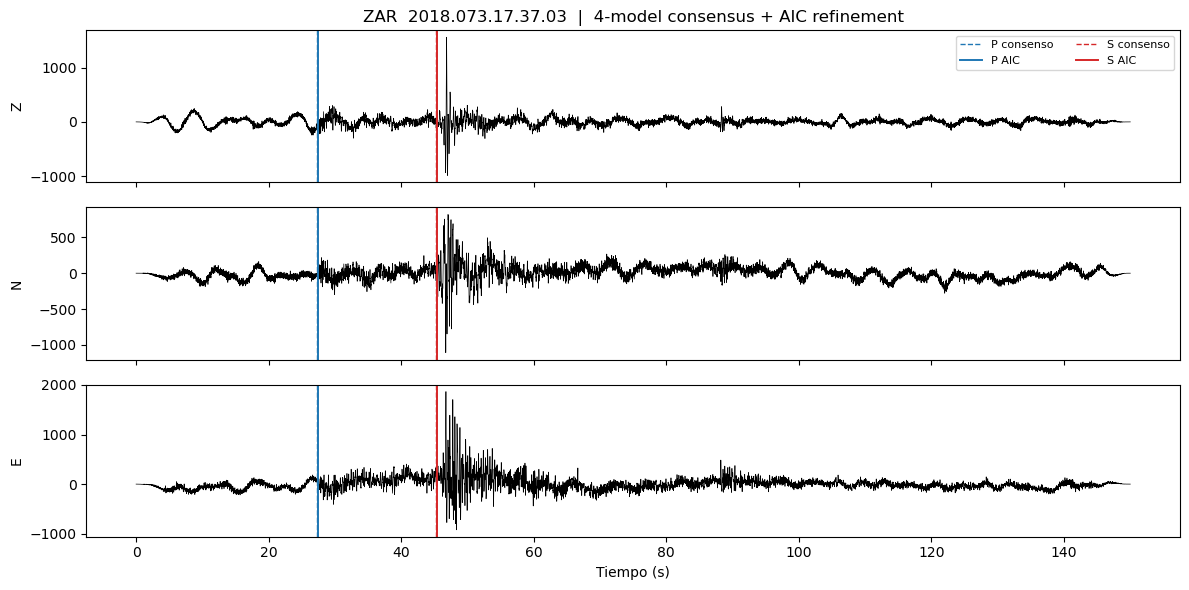

In [ ]:
# ==========================================
# 6. INSPECTOR: one earthquake window, consensus (dashed) vs AIC (solid)
# ==========================================
INSPECT_INDEX = 3   # index within the earthquake windows found above
import matplotlib.pyplot as plt

eqs = [(t_, a, l) for t_, a, l in labs4 if l.category == "earthquake"]
if not eqs:
    print("No earthquake windows in this scan.")
else:
    i = INSPECT_INDEX % len(eqs)
    t_, a, l = eqs[i]
    p_ref, s_ref = refine_ps(a, l.p_sample, l.s_sample)
    sc = per_model_probs(a)
    print(f"{STATION} | earthquake #{i}/{len(eqs)-1} | {t_}")
    print("model            P     S")
    for m in models:
        print(f"  {m:14s} {sc[m]['P']:.2f}  {sc[m]['S']:.2f}")
    print(f"\nP: consensus {l.p_sample}  ->  AIC {p_ref}  ({(p_ref-l.p_sample)/fs*1000:+.0f} ms)")
    if l.s_sample is not None:
        print(f"S: consensus {l.s_sample}  ->  AIC {s_ref}  ({(s_ref-l.s_sample)/fs*1000:+.0f} ms)")

    t = np.arange(NPTS) / fs
    fig, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
    for k, comp in enumerate("ZNE"):
        ax[k].plot(t, a[k], lw=0.5, color="k")
        if l.p_sample is not None:
            ax[k].axvline(l.p_sample / fs, color="tab:blue", lw=1.0, ls="--", label="P consensus")
            ax[k].axvline(p_ref / fs, color="tab:blue", lw=1.4, label="P AIC")
        if l.s_sample is not None:
            ax[k].axvline(l.s_sample / fs, color="tab:red", lw=1.0, ls="--", label="S consensus")
            ax[k].axvline(s_ref / fs, color="tab:red", lw=1.4, label="S AIC")
        ax[k].set_ylabel(comp)
    ax[0].legend(loc="upper right", fontsize=8, ncol=2)
    ax[0].set_title(f"{STATION}  {t_}  |  4-model consensus + AIC refinement")
    ax[-1].set_xlabel("Time (s)")
    fig.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# 7. S-pick reliability across earthquake windows
# ==========================================
# Mark S only when at least MIN_S models agree.
# Windows with a strong P but no S consensus are 'P-only' (S left blank).
print(f"{'idx':>3} {'timestamp':17} {'Pn':>3} {'P_s':>6} {'Sn':>3} {'S_prob':>6} {'S_s':>6}  flag")
for j, (t_, a, l) in enumerate(eqs):
    p_s = f"{l.p_sample/fs:.2f}" if l.p_sample is not None else "-"
    s_s = f"{l.s_sample/fs:.2f}" if l.s_sample is not None else "-"
    flag = ""
    if l.s_sample is None:
        flag += "P-only "
    elif l.s_n_models < 2:
        flag += "S=1model "
    print(f"{j:>3} {t_:17} {l.p_n_models:>3} {p_s:>6} {l.s_n_models:>3} "
          f"{l.s_prob:>6.2f} {s_s:>6}  {flag}")

idx timestamp          Pn    P_s  Sn S_prob    S_s  flag
  0 2018.071.03.24.56   3  29.78   2   0.45  56.59  
  1 2018.071.10.51.21   3  28.31   2   0.35  49.39  
  2 2018.072.06.35.07   4  28.95   4   0.72  37.71  
  3 2018.073.17.37.03   3  27.35   2   0.35  45.28  
  4 2018.074.08.17.32   4  26.02   4   0.39  45.39  
  5 2018.074.22.28.51   3  28.92   2   0.54  49.81  
  6 2018.077.00.36.19   3  28.46   3   0.45  46.88  
  7 2018.078.12.02.05   3  27.51   3   0.31  44.36  


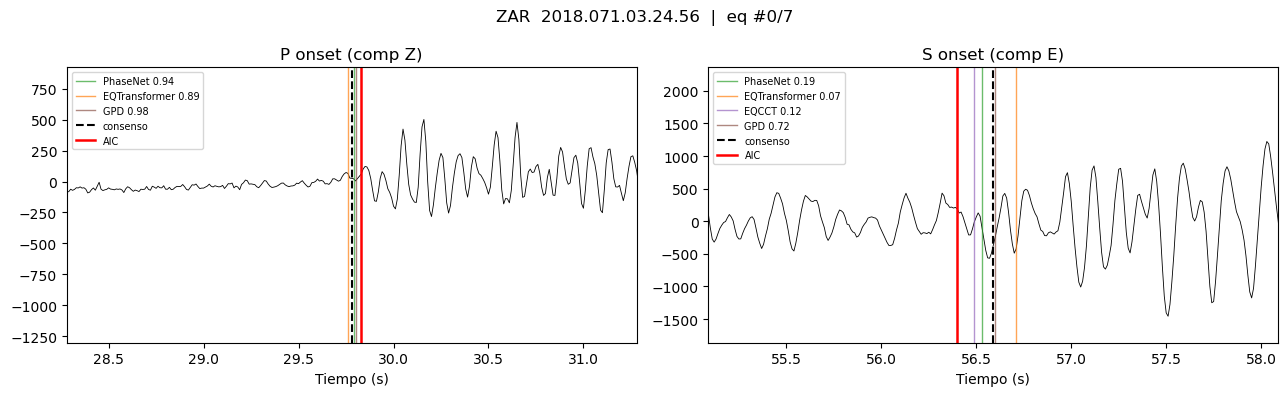

P: consenso=2978 (29.78s)  AIC=2983 (29.83s)
     PhaseNet       2979 (29.79s)  prob 0.94
     EQTransformer  2976 (29.76s)  prob 0.89
     GPD            2980 (29.80s)  prob 0.98
S: consenso=5659 (56.59s)  AIC=5640 (56.40s)
     PhaseNet       5653 (56.53s)  prob 0.19
     EQTransformer  5671 (56.71s)  prob 0.07
     EQCCT          5649 (56.49s)  prob 0.12
     GPD            5660 (56.60s)  prob 0.72


In [ ]:
# ==========================================
# 8. ONSET verification (ZOOM): each model vs consensus vs AIC
# ==========================================
# Compare model, consensus, and AIC onset positions visually.
# The display is diagnostic and does not supply a manual reference.
# Step ONSET_INDEX through selected windows.
ONSET_INDEX = 0        # earthquake window index (within eqs)
ZOOM_S = 1.5           # +/- seconds around the onset
import matplotlib.pyplot as plt

_colors = {"PhaseNet": "tab:green", "EQTransformer": "tab:orange",
           "EQCCT": "tab:purple", "GPD": "tab:brown"}


def model_picks(arr, floor=0.05):
    pks = cu.run_models_on_window(arr, models, thresholds={"P": floor, "S": floor},
                                  station=STATION[:4])
    out = {m: {"P": None, "S": None} for m in models}
    for pk in pks:
        cur = out[pk.model][pk.phase]
        if cur is None or pk.prob > cur[1]:
            out[pk.model][pk.phase] = (pk.sample, pk.prob)
    return out


if not eqs:
    print("No earthquake windows.")
else:
    i = ONSET_INDEX % len(eqs)
    t_, a, l = eqs[i]
    p_ref, s_ref = refine_ps(a, l.p_sample, l.s_sample)
    mp = model_picks(a)
    t = np.arange(NPTS) / fs
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, phase, cons, ref in ((axes[0], "P", l.p_sample, p_ref),
                                 (axes[1], "S", l.s_sample, s_ref)):
        if cons is None:
            ax.set_title(f"{phase}: no consensus")
            continue
        if phase == "P":
            ci = 0
        else:
            w = slice(max(0, cons - 100), min(NPTS, cons + 100))
            ci = 1 if np.abs(a[1][w]).max() >= np.abs(a[2][w]).max() else 2
        ax.plot(t, a[ci], lw=0.6, color="k")
        for m in models:
            pk = mp[m][phase]
            if pk is not None:
                ax.axvline(pk[0] / fs, color=_colors.get(m, "gray"), lw=1.0,
                           alpha=0.7, label=f"{m} {pk[1]:.2f}")
        ax.axvline(cons / fs, color="k", ls="--", lw=1.5, label="consensus")
        ax.axvline(ref / fs, color="red", lw=1.8, label="AIC")
        ax.set_xlim(cons / fs - ZOOM_S, cons / fs + ZOOM_S)
        ax.set_title(f"{phase} onset (comp {'ZNE'[ci]})")
        ax.set_xlabel("Time (s)")
        ax.legend(fontsize=7)
    fig.suptitle(f"{STATION}  {t_}  |  eq #{i}/{len(eqs)-1}")
    fig.tight_layout()
    plt.show()

    print(f"P: consensus={l.p_sample} ({l.p_sample/fs:.2f}s)  AIC={p_ref} ({p_ref/fs:.2f}s)")
    for m in models:
        pk = mp[m]["P"]
        if pk:
            print(f"     {m:14s} {pk[0]} ({pk[0]/fs:.2f}s)  prob {pk[1]:.2f}")
    if l.s_sample is not None:
        print(f"S: consensus={l.s_sample} ({l.s_sample/fs:.2f}s)  AIC={s_ref} ({s_ref/fs:.2f}s)")
        for m in models:
            pk = mp[m]["S"]
            if pk:
                print(f"     {m:14s} {pk[0]} ({pk[0]/fs:.2f}s)  prob {pk[1]:.2f}")

Per-phase SNR QC | cut = 0.0 dB | win = 5 s

timestamp           P_SNR   S_SNR  action
2018.071.03.24.56    14.1     8.5  keep P+S
2018.071.10.51.21     1.4     7.4  keep P+S
2018.072.06.35.07    11.2    11.0  keep P+S
2018.073.17.37.03    -0.3    13.1  keep S (drop P)
2018.074.08.17.32     8.7    11.8  keep P+S
2018.074.22.28.51    12.9    11.2  keep P+S
2018.077.00.36.19    28.4    12.8  keep P+S
2018.078.12.02.05     7.7    11.0  keep P+S

Result: 8/8 stay earthquake, 0 -> unlabelled  |  dropped picks: P x1, S x0


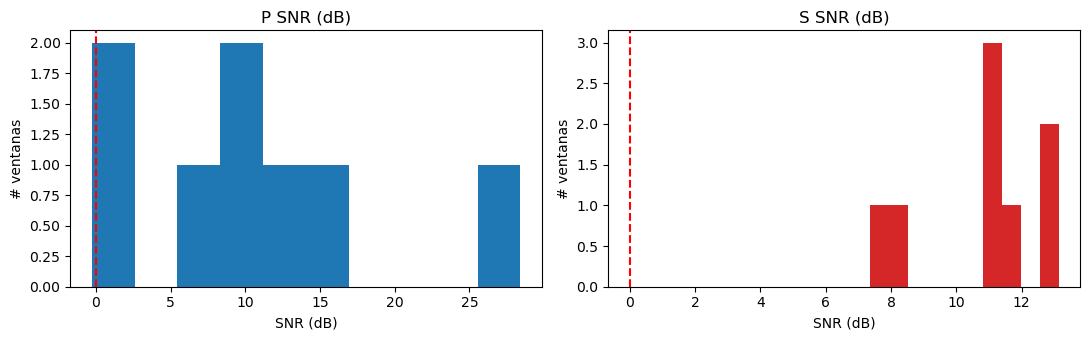

In [ ]:
# ==========================================
# 9. SNR quality control (OPTION 3: per-phase)
# ==========================================
# Use five-second pre/post-pick RMS windows for each phase.
# Drop only picks below SNR_CUT; an event retains any surviving phase.
# If neither phase remains, classify the window as unlabelled.
# The pre-S interval may contain P coda.
import matplotlib.pyplot as plt

SNR_CUT = 0.0        # dB; per-phase quality threshold
SNR_WIN_S = 5.0      # s; noise/signal window length on each side of the pick


def snr_db(arr, sample, comp_idx, win_s=SNR_WIN_S):
    n = int(win_s * fs)
    if sample is None or sample - n < 0 or sample + n > NPTS:
        return float("nan")
    x = arr[comp_idx]
    rms_n = np.sqrt(np.mean(x[sample - n:sample] ** 2)) + 1e-12
    rms_s = np.sqrt(np.mean(x[sample:sample + n] ** 2)) + 1e-12
    return 20.0 * np.log10(rms_s / rms_n)


def s_component(arr, s_sample):
    w = slice(max(0, s_sample - 100), min(NPTS, s_sample + 100))
    return 1 if np.abs(arr[1][w]).max() >= np.abs(arr[2][w]).max() else 2


rows = []            # (timestamp, p_snr, s_snr, keep_p, keep_s, final_category, action)
for t_, a, l in eqs:
    p_snr = snr_db(a, l.p_sample, 0)
    s_snr = snr_db(a, l.s_sample, s_component(a, l.s_sample)) if l.s_sample is not None else float("nan")
    keep_p = (l.p_sample is not None) and (p_snr >= SNR_CUT)
    keep_s = (l.s_sample is not None) and (s_snr >= SNR_CUT)
    if keep_p and keep_s:
        cat_, act = "earthquake", "keep P+S"
    elif keep_p:
        cat_, act = "earthquake", "keep P (drop S)" if l.s_sample is not None else "keep P (P-only)"
    elif keep_s:
        cat_, act = "earthquake", "keep S (drop P)"
    else:
        cat_, act = "unlabelled", "-> unlabelled"
    rows.append((t_, p_snr, s_snr, keep_p, keep_s, cat_, act))

print(f"Per-phase SNR QC | cut = {SNR_CUT:.1f} dB | win = {SNR_WIN_S:.0f} s\n")
print(f"{'timestamp':17} {'P_SNR':>7} {'S_SNR':>7}  action")
for t_, p, s, kp, ks, cat_, act in rows:
    s_str = f"{s:>7.1f}" if not np.isnan(s) else f"{'--':>7}"
    print(f"{t_:17} {p:>7.1f} {s_str}  {act}")

n_eq = sum(1 for r in rows if r[5] == "earthquake")
n_unl = sum(1 for r in rows if r[5] == "unlabelled")
n_dropP = sum(1 for r in rows if (not r[3]) and r[5] == "earthquake")
n_dropS = sum(1 for r in rows if (not r[4]) and (r[2] == r[2]) and r[5] == "earthquake")
print(f"\nResult: {n_eq}/{len(rows)} stay earthquake, {n_unl} -> unlabelled"
      f"  |  dropped picks: P x{n_dropP}, S x{n_dropS}")

pS = np.array([r[1] for r in rows], float)
sS = np.array([r[2] for r in rows], float)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(pS[~np.isnan(pS)], bins=10, color="tab:blue")
ax[0].axvline(SNR_CUT, color="r", ls="--")
ax[0].set_title("P SNR (dB)")
ax[1].hist(sS[~np.isnan(sS)], bins=10, color="tab:red")
ax[1].axvline(SNR_CUT, color="r", ls="--")
ax[1].set_title("S SNR (dB)")
for a_ in ax:
    a_.set_xlabel("SNR (dB)")
    a_.set_ylabel("# windows")
fig.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 10. EXPLORE NOISE SOURCES
# ==========================================
# Candidate noise sources already present in the waveform windows:
#   (a) pre-event slices: every window is [P_teo-30 s, P_teo+120 s]; the first
#       early segment precedes the theoretical P but still needs checking.
#       Its suitability cannot be assumed for every event.
#   (b) consensus-'noise' windows: 150 s where no model fires (real ambient noise,
#       ready in the final format, but could rarely hide a missed event).
from scipy.stats import kurtosis

PRE_A, PRE_B = 200, 2700   # pre-event slice: [2 s, 27 s], safe margin before P (3000)

noise_wins = [(t_, a) for t_, a, l in labs4 if l.category == "noise"]
unl_wins = [(t_, a) for t_, a, l in labs4 if l.category == "unlabelled"]
eqs_l = [(t_, a, l) for t_, a, l in labs4 if l.category == "earthquake"]

pre_noise = [a[:, PRE_A:PRE_B] for _, a in cat]   # one clean noise sample per window
pre_dur = (PRE_B - PRE_A) / fs

print(f"Catalog windows scanned          : {len(cat)}")
print(f"  earthquake                     : {len(eqs_l)}")
print(f"  consensus 'noise' (150 s)      : {len(noise_wins)}   -> usable as-is")
print(f"  unlabelled                     : {len(unl_wins)}")
print(f"\nFree noise bank:")
print(f"  pre-event slices ({pre_dur:.0f} s each) : {len(pre_noise)}   -> 1 per window, guaranteed pre-P")
print(f"  total real noise available     : {len(noise_wins) + len(pre_noise)}"
      f"  (consensus-noise + pre-event)")

# Use vertical kurtosis as a screening statistic, not a phase reference.
kv_pre = np.array([kurtosis(a[0, PRE_A:PRE_B]) for _, a in cat])
kv_evt = np.array([kurtosis(a[0, max(0, l.p_sample - 200):l.p_sample + 800])
                   for _, a, l in eqs_l if l.p_sample is not None])
print(f"\nKurtosis (vertical, higher = peakier/event-like):")
print(f"  pre-event slices : median={np.median(kv_pre):5.1f}  max={kv_pre.max():5.1f}")
print(f"  around P (event) : median={np.median(kv_evt):5.1f}  min={kv_evt.min():5.1f}")
print("  -> pre-event stays flat while event windows spike: pre-event noise is clean.")

Catalog windows scanned          : 30
  earthquake                     : 8
  consensus 'noise' (150 s)      : 3   -> usable as-is
  unlabelled                     : 19

Free noise bank:
  pre-event slices (25 s each) : 30   -> 1 per window, guaranteed pre-P
  total real noise available     : 33  (consensus-noise + pre-event)

Kurtosis (vertical, higher = peakier/event-like):
  pre-event slices : median= -0.2  max=  2.4
  around P (event) : median=  0.7  min= -0.3
  -> pre-event stays flat while event windows spike: pre-event noise is clean.


In [ ]:
# ==========================================
# 11. MINI-TEST: write a tiny SeisBench dataset (earthquake + noise) and read it back
# ==========================================
# Write earthquake traces and real/synthetic noise to a diagnostic dataset.
# Synthetic noise uses a pre-event segment from the same window.
import shutil
import seisbench.data as sbd

OUT = REPO_ROOT / "data" / "interim" / "dataset_minitest"
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)

NOISE_LEN_S = 70                      # >= 60 s so it serves EQT/EQCCT (largest window)
NOISE_NPTS = int(NOISE_LEN_S * fs)    # 7000 samples


def synth_noise_len(arr, n_out):
    """Seam-free noise of length n_out with the REAL pre-event (PRE_A:PRE_B) spectrum."""
    seg = arr[:, PRE_A:PRE_B]
    res = np.zeros((3, n_out), dtype=np.float32)
    for i in range(3):
        s = seg[i] - seg[i].mean()
        R = np.abs(np.fft.rfft(s))
        amp = np.interp(np.linspace(0, 1, n_out // 2 + 1),
                        np.linspace(0, 1, R.size), R)
        n = np.fft.irfft(amp * np.exp(1j * _rng.uniform(0, 2 * np.pi, amp.size)), n=n_out)
        res[i] = (n / (n.std() + 1e-9) * (s.std() + 1e-9)).astype(np.float32)
    return np.ascontiguousarray(res)


def snr_qc_arrivals(a, l):
    """Per-phase SNR QC: keep only picks whose SNR >= SNR_CUT (option 3)."""
    p = l.p_sample if (l.p_sample is not None and snr_db(a, l.p_sample, 0) >= SNR_CUT) else None
    s = None
    if l.s_sample is not None and snr_db(a, l.s_sample, s_component(a, l.s_sample)) >= SNR_CUT:
        s = l.s_sample
    return p, s


n_eq = n_noise = 0
with sbd.WaveformDataWriter(OUT / "metadata.csv", OUT / "waveforms.hdf5") as w:
    w.data_format = {
        "dimension_order": "CW",
        "component_order": "ZNE",
        "sampling_rate": fs,
        "measurement": "velocity",
        "unit": "counts",
        "instrument_response": "not restituted",
    }
    for t_, a, l in eqs_l:
        p_s, s_s = snr_qc_arrivals(a, l)
        if p_s is None and s_s is None:
            continue  # both phases failed SNR -> would be 'unlabelled', skip
        w.add_trace({
            "source_id": f"{STATION}_{t_}",
            "station_network_code": "CM", "station_code": STATION,
            "trace_category": "earthquake_local",
            "trace_sampling_rate_hz": fs,
            "trace_p_arrival_sample": p_s,
            "trace_s_arrival_sample": s_s,
            "split": "train",
        }, a.astype(np.float32))
        n_eq += 1
        # (b) synthetic-prolonged noise (70 s) from the SAME window's real pre-event
        w.add_trace({
            "source_id": f"{STATION}_{t_}_synthnoise",
            "station_network_code": "CM", "station_code": STATION,
            "trace_category": "noise",
            "trace_sampling_rate_hz": fs,
            "trace_p_arrival_sample": None,
            "trace_s_arrival_sample": None,
            "split": "train",
        }, synth_noise_len(a, NOISE_NPTS))
        n_noise += 1
    for t_, a in noise_wins:
        w.add_trace({
            "source_id": f"{STATION}_{t_}_noise",
            "station_network_code": "CM", "station_code": STATION,
            "trace_category": "noise",
            "trace_sampling_rate_hz": fs,
            "trace_p_arrival_sample": None,
            "trace_s_arrival_sample": None,
            "split": "train",
        }, a.astype(np.float32))
        n_noise += 1

print(f"Wrote {n_eq} earthquake + {n_noise} noise traces to {OUT}")

# --- read it back to confirm it is a valid SeisBench dataset ---
ds = sbd.WaveformDataset(OUT, sampling_rate=fs)
print("\nReloaded:", ds)
print(ds.metadata["trace_category"].value_counts().to_string())
wf0 = ds.get_waveforms(0)
print(f"\nfirst trace shape = {wf0.shape}  "
      f"(P={ds.metadata.iloc[0].get('trace_p_arrival_sample')}, "
      f"S={ds.metadata.iloc[0].get('trace_s_arrival_sample')})")


Traces converted: 0it [00:00, ?it/s]


Traces converted: 19it [00:00, 707.19it/s]

Wrote 8 earthquake + 11 noise traces to M:\Github\TFM_SeismicPhasePicker_ColombianAndes\data\interim\dataset_minitest

Reloaded: Unnamed dataset - 19 traces
trace_category
noise               11
earthquake_local     8

first trace shape = (3, 15001)  (P=2978.0, S=5659.0)
